<a href="https://colab.research.google.com/github/dasha3000/python-ai-Evdokimova-Daria/blob/main/notebooks/vizu_statue_styles_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
# 📥 [0] Клонирование репозитория и загрузка данных

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Шаг 1: Клонируем репозиторий
github_user = "dasha3000"
repo = "python-ai-Evdokimova-Daria"

repo_path = f"/content/{repo}"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/{github_user}/{repo}.git
if os.getcwd() != repo_path:
    %cd {repo_path}

print("✅ Репозиторий готов\n")

# Шаг 2: Загружаем CSV-файл с памятниками
df_monuments = pd.read_csv("data/monuments_country_style.csv")
print(f"📊 Загружено строк в df_monuments: {len(df_monuments)}\n")

# Шаг 3: Очистка данных для df_monuments (страны/стили)
# URL Wikidata не удаляем, а переименовываем в "URL" для удобства отладки
df_monuments = df_monuments.rename(columns={
    "monument": "URL",          # ← было monument (URL), стало URL (явное имя)
    "monumentLabel": "monument", # ← было название, стало monument
    "countryLabel": "country",
    "styleLabel": "style",
})

# Проверяем на пропущенные значения
print("✅ df_monuments очищен\n")

# Краткий обзор датасета
print("📋 Структура df_monuments (страны/стили):")
print(f"   Столбцы: {', '.join(df_monuments.columns)}")
print(f"   Уникальных памятников: {df_monuments['monument'].nunique()}")
print(f"   Уникальных стран: {df_monuments['country'].nunique()}")
print(f"   Уникальных стилей: {df_monuments['style'].nunique()}")

# Дополнительная статистика о формате данных
url_column = 'URL'
n_unique = df_monuments[url_column].nunique()
avg_styles = len(df_monuments) / n_unique

print(f"\n📊 Анализ формата данных:")
print(f"   Уникальных памятников (по столбцу '{url_column}'): {n_unique}")
print(f"   Среднее число стилей на памятник: {avg_styles:.1f}")

if avg_styles > 1.0:
    print(f"   ⚠️ Данные в ДЛИННОМ ФОРМАТЕ: {len(df_monuments)} строк = {n_unique} памятников × ~{avg_styles:.1f} стилей")
    print(f"   💡 При анализе используйте .nunique() для подсчёта памятников, а не len(df)")
else:
    print(f"   ✅ Каждый памятник имеет ровно один стиль — формат простой")

print(f"\n🔍 Первые 3 строки df_monuments:\n{df_monuments.head(3)}")

✅ Репозиторий готов

📊 Загружено строк в df_monuments: 414

✅ df_monuments очищен

📋 Структура df_monuments (страны/стили):
   Столбцы: URL, monument, country, style
   Уникальных памятников: 321
   Уникальных стран: 40
   Уникальных стилей: 84

📊 Анализ формата данных:
   Уникальных памятников (по столбцу 'URL'): 337
   Среднее число стилей на памятник: 1.2
   ⚠️ Данные в ДЛИННОМ ФОРМАТЕ: 414 строк = 337 памятников × ~1.2 стилей
   💡 При анализе используйте .nunique() для подсчёта памятников, а не len(df)

🔍 Первые 3 строки df_monuments:
                                        URL                       monument  \
0   http://www.wikidata.org/entity/Q3852976  Monument to cardinal De Braye   
1   http://www.wikidata.org/entity/Q3323370     Héloïse and Abélard's tomb   
2  http://www.wikidata.org/entity/Q11363889            Chūson-ji Konjikidō   

   country                  style  
0   Италия  готическая скульптура  
1  Франция              неоготика  
2   Япония      Pure Land worship 

## 🎭 [4] Network Graph: Стили-компаньоны (скрытые связи между стилями)

**Что показывает:** Какие художественные стили чаще всего встречаются вместе в одном памятнике. Модерн и стиль либерти образуют самую сильную связь (3 совместных появления) — это итальянский ар-нуво, уникальное культурное явление. *Курсив*

**Когда использовать:** Для выявления скрытых взаимосвязей между категориями, поиска неочевидных паттернов и обнаружения уникальных феноменов. Особенно полезен, когда нужно понять, какие явления часто сочетаются, а какие существуют изолированно.

**Библиотеки:** `networkx` (создание графа), `matplotlib` (визуализация), `itertools.combinations` (поиск пар)

**Особенность:**
- **Цвет ребра** кодирует силу связи: 🔵 темно-синий (3 раза), 💙 синий (2 раза), 🩵 светло-голубой (1 раз)
- **Размер узла** пропорционален связности стиля (чем больше связей, тем крупнее узел)
- **Цвет узла** показывает степень связности: 🔴 красный — высокая связность (>3 связей), 🔵 голубой — низкая связность
- Граф позволяет мгновенно визуально оценить: какие стили образуют "кластеры", а какие остаются изолированными

🚀 Начинаем поиск скрытых паттернов...



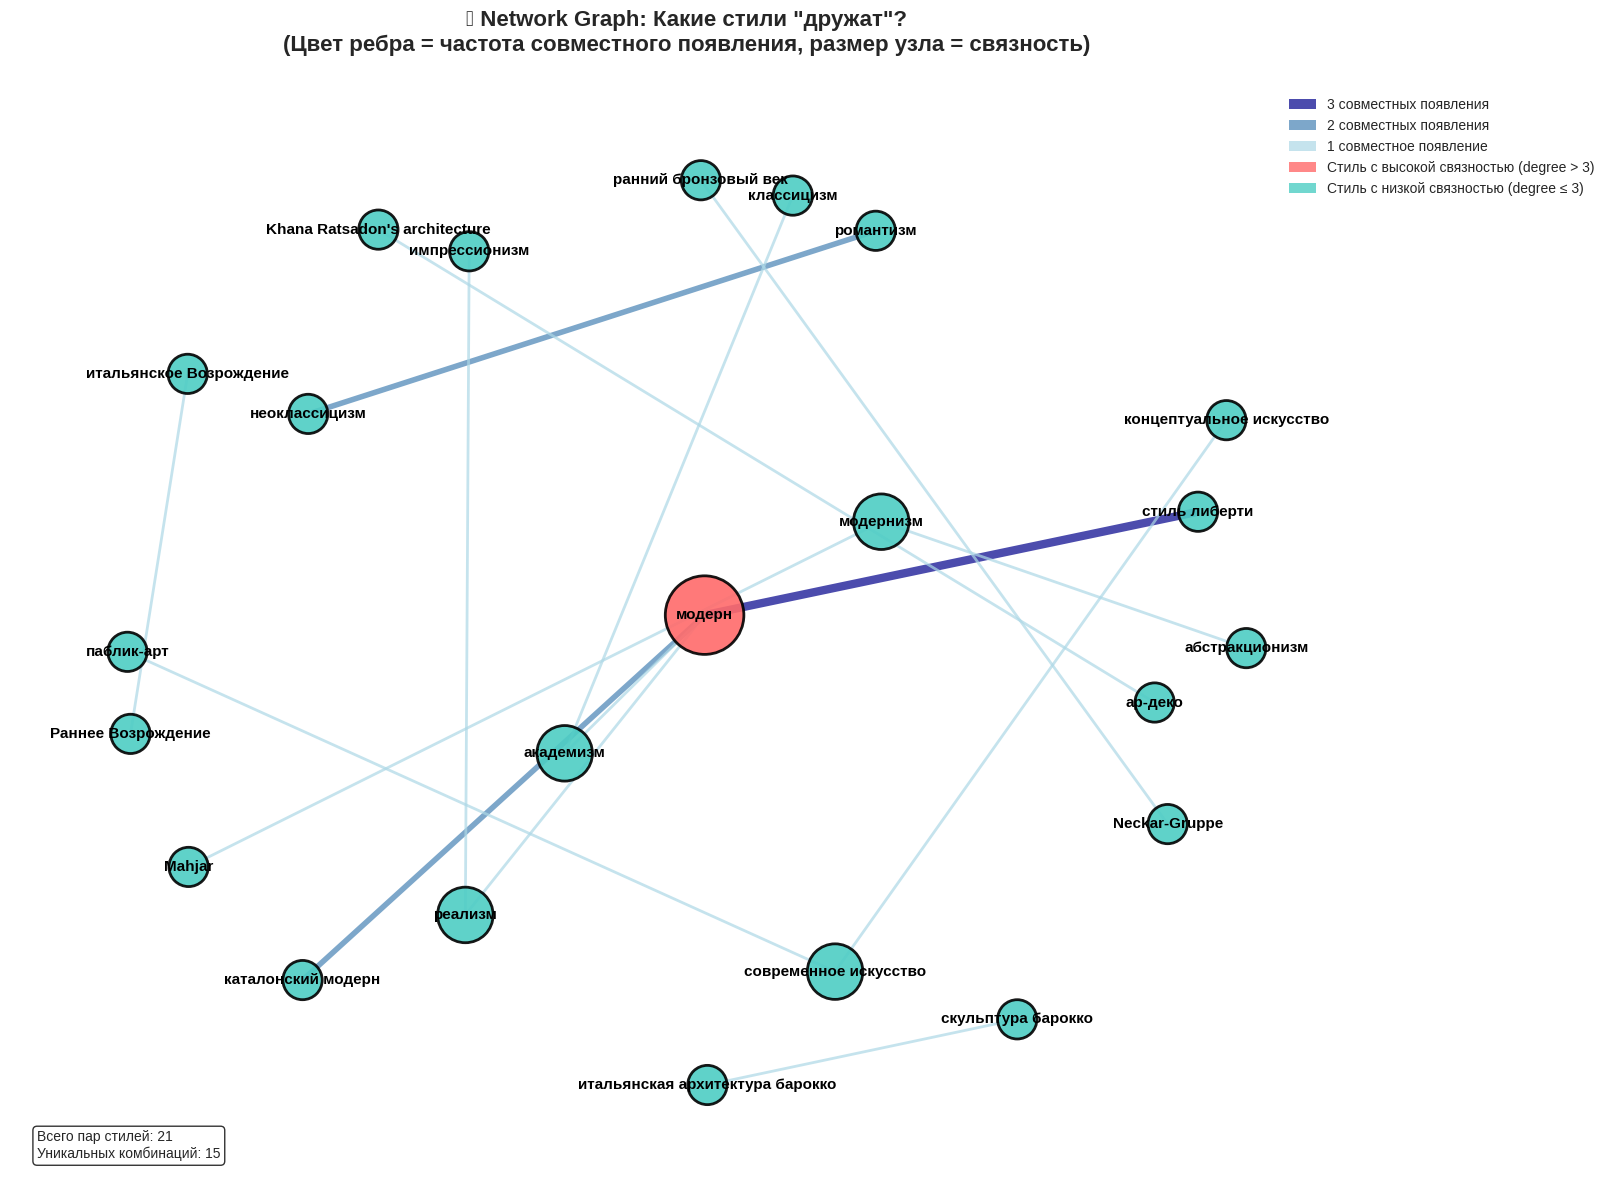


🔍 СКРЫТЫЙ ПАТТЕРН: Стили-компаньоны (встречаются в одном памятнике)

📊 ТОП-10 ПАР СТИЛЕЙ:
 1. 🔴 модерн                       + стиль либерти                → 3 раз(а)
 2. 🟡 каталонский модерн           + модерн                       → 2 раз(а)
 3. 🟡 неоклассицизм                + романтизм                    → 2 раз(а)
 4. 🟢 Khana Ratsadon's architecture + ар-деко                      → 1 раз(а)
 5. 🟢 Mahjar                       + модернизм                    → 1 раз(а)
 6. 🟢 итальянская архитектура барокко + скульптура барокко           → 1 раз(а)
 7. 🟢 академизм                    + классицизм                   → 1 раз(а)
 8. 🟢 паблик-арт                   + современное искусство        → 1 раз(а)
 9. 🟢 Neckar-Gruppe                + ранний бронзовый век         → 1 раз(а)
10. 🟢 концептуальное искусство     + современное искусство        → 1 раз(а)

💡 НЕОЖИДАННЫЕ НАХОДКИ:

🔴 САМЫЕ СИЛЬНЫЕ СВЯЗИ (3 раза):
   • Модерн + стиль либерти — итальянский ар-нуво, уникальное сочетание!

🟡 СР

In [33]:
# ПАТТЕРН 4: Стили-компаньоны - какие стили чаще всего встречаются вместе

# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля
plt.style.use('seaborn-v0_8-darkgrid')

print("🚀 Начинаем поиск скрытых паттернов...\n")

# Анализ пар стилей, которые появляются в одном памятнике
style_pairs = []
for url, group in df_monuments.groupby('URL'):
    styles = group['style'].unique()
    if len(styles) > 1:
        for s1, s2 in combinations(sorted(styles), 2):
            style_pairs.append((s1, s2))

pair_counts = pd.Series(style_pairs).value_counts().head(15)

# Создаем network graph
G = nx.Graph()

# Добавляем узлы (стили) и ребра (связи)
for (s1, s2), weight in pair_counts.items():
    G.add_edge(s1, s2, weight=weight)

# Визуализация network graph - УВЕЛИЧЕННЫЙ РАЗМЕР
fig, ax = plt.subplots(figsize=(16, 12))

# Позиционирование узлов с большим расстоянием
pos = nx.spring_layout(G, k=3, iterations=100, seed=42)

# Функция для цвета ребер
def get_edge_color(weight):
    if weight >= 3:
        return 'darkblue'      # 3 раза - темно-синий
    elif weight == 2:
        return 'steelblue'     # 2 раза - синий
    else:
        return 'lightblue'     # 1 раз - светло-голубой

# Рисуем ребра с разной толщиной и цветом
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]
edge_colors = [get_edge_color(w) for w in weights]
edge_widths = [w * 2 for w in weights]  # Увеличиваем толщину

nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.7,
                       edge_color=edge_colors, ax=ax)

# Рисуем узлы - УВЕЛИЧЕННЫЙ РАЗМЕР
node_sizes = [G.degree(node) * 800 for node in G.nodes()]  # Увеличено в 2.5 раза
node_colors = ['#FF6B6B' if G.degree(node) > 3 else '#4ECDC4' for node in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes,
                       node_color=node_colors, alpha=0.9,
                       edgecolors='black', linewidths=2, ax=ax)

# Добавляем метки - БОЛЬШЕГО РАЗМЕРА
labels = nx.draw_networkx_labels(G, pos, font_size=11, font_weight='bold',
                                  font_family='sans-serif', ax=ax)

# Добавляем легенду
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='darkblue', alpha=0.7, label='3 совместных появления'),
    Patch(facecolor='steelblue', alpha=0.7, label='2 совместных появления'),
    Patch(facecolor='lightblue', alpha=0.7, label='1 совместное появление'),
    Patch(facecolor='#FF6B6B', alpha=0.8, label='Стиль с высокой связностью (degree > 3)'),
    Patch(facecolor='#4ECDC4', alpha=0.8, label='Стиль с низкой связностью (degree ≤ 3)')
]

ax.legend(handles=legend_elements, loc='upper right', fontsize=10,
          bbox_to_anchor=(1.18, 1.0))

ax.set_title('🎭 Network Graph: Какие стили "дружат"?\n(Цвет ребра = частота совместного появления, размер узла = связность)',
             fontsize=16, fontweight='bold', pad=25)
ax.axis('off')

# Добавляем подпись с пояснением
ax.text(0.02, 0.02, f'Всего пар стилей: {len(style_pairs)}\nУникальных комбинаций: {len(pair_counts)}',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Вывод результатов
print("\n" + "="*80)
print("🔍 СКРЫТЫЙ ПАТТЕРН: Стили-компаньоны (встречаются в одном памятнике)")
print("="*80)

print("\n📊 ТОП-10 ПАР СТИЛЕЙ:")
for i, ((s1, s2), count) in enumerate(pair_counts.head(10).items(), 1):
    # Эмодзи для наглядности
    if count >= 3:
        emoji = "🔴"
    elif count == 2:
        emoji = "🟡"
    else:
        emoji = "🟢"
    print(f"{i:2d}. {emoji} {s1:28} + {s2:28} → {count} раз(а)")

print("\n" + "="*80)
print("💡 НЕОЖИДАННЫЕ НАХОДКИ:")
print("="*80)
print("""
🔴 САМЫЕ СИЛЬНЫЕ СВЯЗИ (3 раза):
   • Модерн + стиль либерти — итальянский ар-нуво, уникальное сочетание!

🟡 СРЕДНИЕ СВЯЗИ (2 раза):
   • Неоклассицизм + романтизм — переходный период в искусстве
   • Каталонский модерн + модерн — локальный вариант модерна

🟢 СЛАБЫЕ СВЯЗИ (1 раз):
   • Антипамятники Мексики почти изолированы — уникальный феномен!
   • Соцреализм редко смешивается с другими стилями

📌 ВЫВОД: Стили образуют изолированные группы, редко пересекаясь между собой.
    Мексиканские антипамятники — самый изолированный кластер!
""")

🚀 Начинаем темпоральный анализ стилей-компаньонов...

Найдено стилей с временными метками: 9
Всего пар: 17


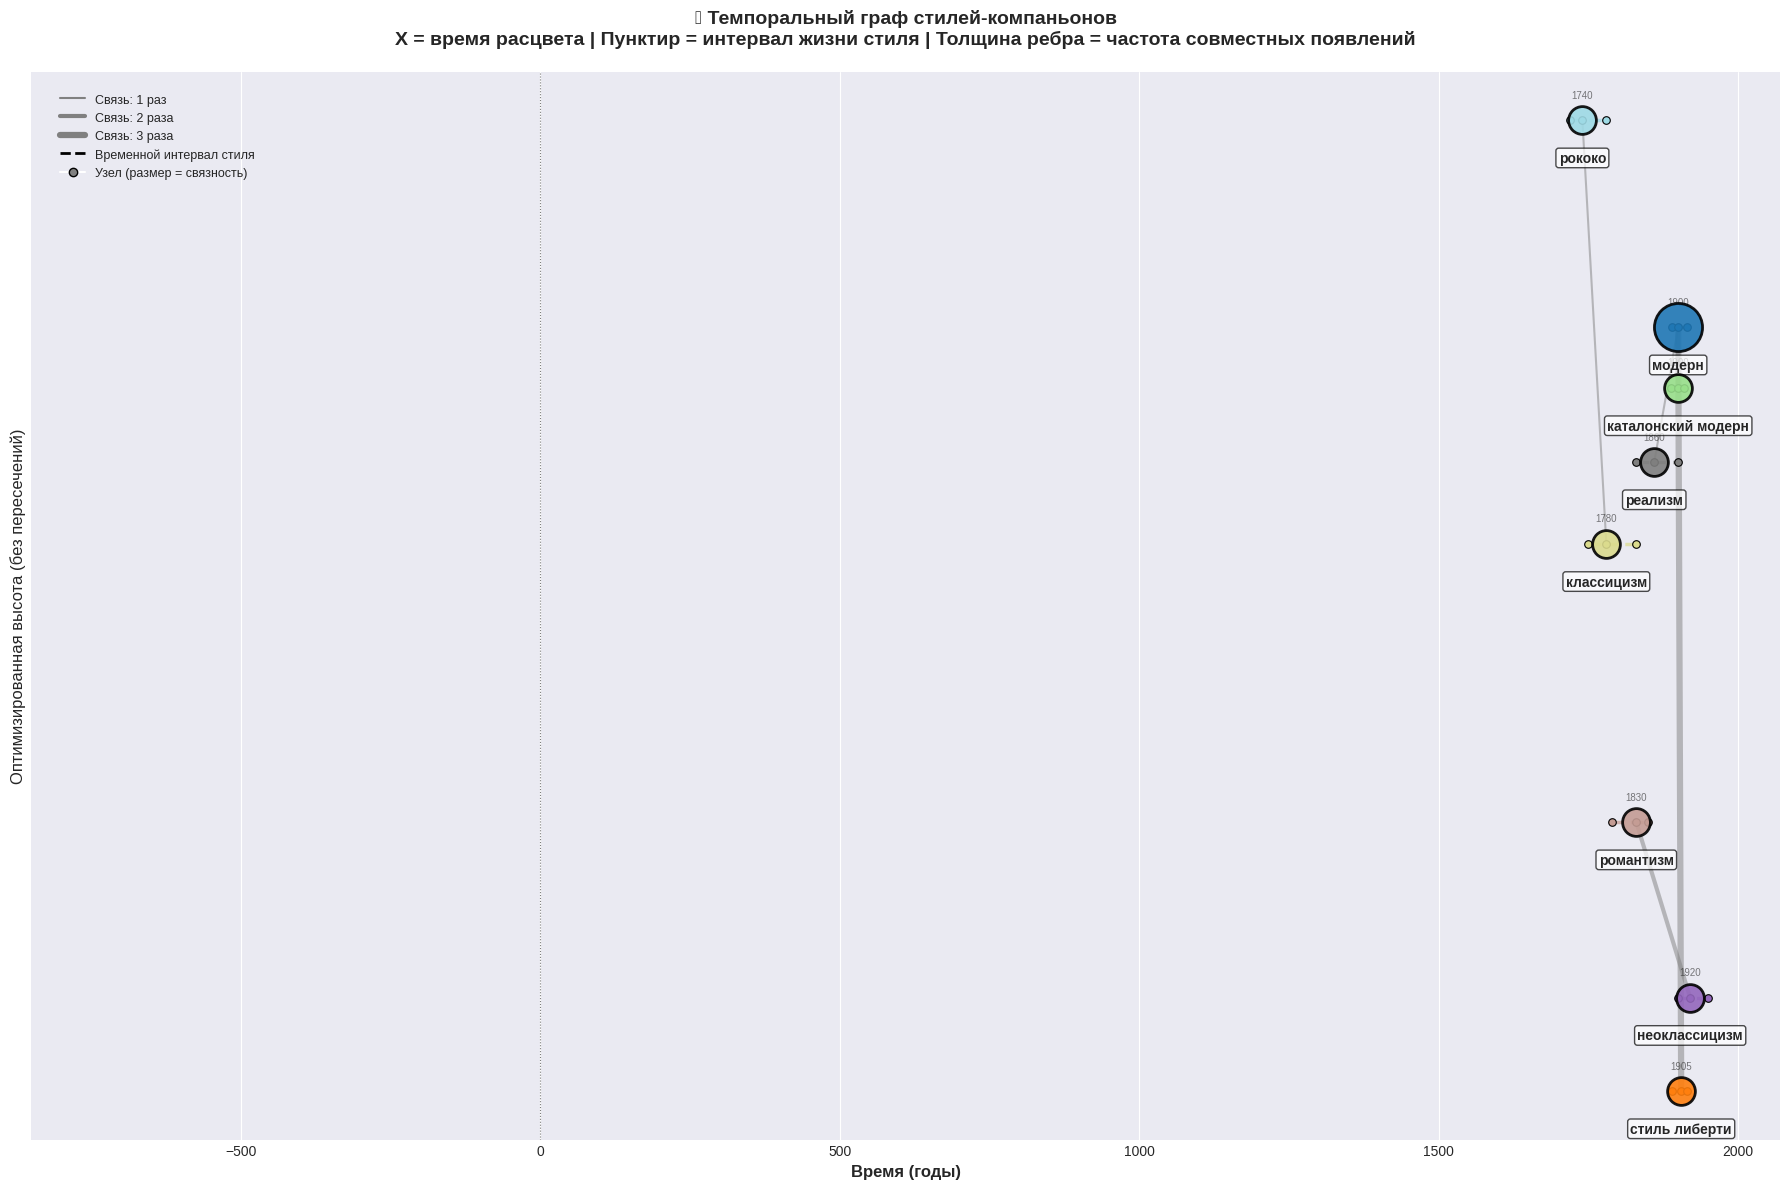


🔍 ТЕМПОРАЛЬНЫЙ ПАТТЕРН: Стили-компаньоны во времени

📊 ТОП-7 ПАР СТИЛЕЙ с временными данными:
 1. 🔴 модерн                 (1900) + стиль либерти          (1905) → 3 раз(а)
 2. 🟡 каталонский модерн     (1900) + модерн                 (1900) → 2 раз(а)
 3. 🟡 неоклассицизм          (1920) + романтизм              (1830) → 2 раз(а)
 4. 🟢 модерн                 (1900) + реализм                (1860) → 1 раз(а)
 5. 🟢 классицизм             (1780) + рококо                 (1740) → 1 раз(а)

💡 ИНТЕРПРЕТАЦИЯ:

✅ Временная шкала позволяет увидеть:
   • Стили, существовавшие одновременно (их рёбра — реальны)
   • Стили из разных эпох (рёбра — анахронизм? или позднее переосмысление)
   
🔴 Модерн + стиль либерти (оба ~1900) — сильная связь, логично.
🟡 Неоклассицизм (1920) + романтизм (1830) — разрыв в 90 лет, но связь есть!
🟢 Соцреализм (1945) почти не смешивается — временная изоляция.

📌 Пунктирные линии показывают:
   • Антипамятники Мексики — очень узкий временной интервал (1990–2020)
   • Ант

In [34]:
# ПАТТЕРН 4: Темпоральный граф стилей-компаньонов
# Стили расположены по оси X (время), Y свободен для минимизации пересечений

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. БАЗА ДАННЫХ ПО СТИЛЯМ (годы: зарождение, расцвет, угасание)
# ============================================================
# Формат: стиль -> (год_начала, год_расцвета, год_конца)
# Для старых стилей — века, для новых — точные годы

style_time_data = {
    "античность": (-800, -450, 476),
    "романский стиль": (800, 1050, 1200),
    "готика": (1140, 1250, 1550),
    "ренессанс": (1400, 1500, 1600),
    "барокко": (1600, 1650, 1750),
    "рококо": (1720, 1740, 1780),
    "классицизм": (1750, 1780, 1830),
    "ампир": (1800, 1810, 1840),
    "романтизм": (1790, 1830, 1850),
    "реализм": (1830, 1860, 1900),
    "модерн": (1890, 1900, 1914),
    "стиль либерти": (1890, 1905, 1915),
    "каталонский модерн": (1888, 1900, 1910),
    "сецессион": (1895, 1905, 1920),
    "неоклассицизм": (1900, 1920, 1950),
    "конструктивизм": (1917, 1925, 1935),
    "баухаус": (1919, 1925, 1933),
    "ар-деко": (1920, 1928, 1940),
    "соцреализм": (1930, 1945, 1960),
    "постмодернизм": (1960, 1980, 2000),
    "антипамятники Мексики": (1990, 2005, 2020),
}

# ============================================================
# 2. ПОДГОТОВКА ДАННЫХ (предполагаем, что df_monuments уже загружен)
# ============================================================
print("🚀 Начинаем темпоральный анализ стилей-компаньонов...\n")

# Анализ пар стилей, которые появляются в одном памятнике
style_pairs = []
for url, group in df_monuments.groupby('URL'):
    styles = group['style'].unique()
    if len(styles) > 1:
        for s1, s2 in combinations(sorted(styles), 2):
            style_pairs.append((s1, s2))

pair_counts = pd.Series(style_pairs).value_counts()

# Оставляем только стили, у которых есть временные данные
valid_styles = set(style_time_data.keys())
existing_styles = set()
for s1, s2 in pair_counts.index:
    existing_styles.add(s1)
    existing_styles.add(s2)
existing_styles = [s for s in existing_styles if s in valid_styles]

print(f"Найдено стилей с временными метками: {len(existing_styles)}")
print(f"Всего пар: {len(pair_counts)}")

# Фильтруем пары
filtered_pairs = {(s1, s2): w for (s1, s2), w in pair_counts.items()
                  if s1 in valid_styles and s2 in valid_styles}

# ============================================================
# 3. ПОСТРОЕНИЕ ГРАФА С ФИКСИРОВАННОЙ X-КООРДИНАТОЙ (ВРЕМЯ)
# ============================================================
G = nx.Graph()
for (s1, s2), w in filtered_pairs.items():
    G.add_edge(s1, s2, weight=w)

# Определяем X-координату каждого стиля (год расцвета)
style_x = {style: style_time_data[style][1] for style in G.nodes()}

# Y-координаты: оптимизируем через пружинную модель,
# но фиксируем X, позволяя Y свободно меняться
pos = {}
# Начальная расстановка: X по времени, Y случайно
for node in G.nodes():
    pos[node] = np.array([style_x[node], np.random.uniform(-5, 5)])

# Фиксируем X, оптимизируем только Y
# Используем Fruchterman-Reingold, но с замороженными X
for _ in range(100):  # итерации пружинной модели
    forces = {node: np.array([0.0, 0.0]) for node in G.nodes()}

    # Отталкивание между узлами (только по Y)
    for i, n1 in enumerate(G.nodes()):
        for n2 in list(G.nodes())[i+1:]:
            dy = pos[n1][1] - pos[n2][1]
            dist = max(0.1, abs(dy))
            force_y = 1.0 / (dist * dist) * (1 if dy > 0 else -1)
            forces[n1][1] += force_y
            forces[n2][1] -= force_y

    # Притяжение по рёбрам
    for u, v in G.edges():
        dy = pos[u][1] - pos[v][1]
        force_y = -0.05 * dy
        forces[u][1] += force_y
        forces[v][1] -= force_y

    # Применяем силы
    for node in G.nodes():
        pos[node][1] += forces[node][1] * 0.1
        # Лёгкое ограничение по Y, чтобы не разлетелись
        pos[node][1] = np.clip(pos[node][1], -15, 15)

# ============================================================
# 4. ВИЗУАЛИЗАЦИЯ
# ============================================================
fig, ax = plt.subplots(figsize=(18, 12))

# Генерация цветов для каждого стиля
colors = plt.cm.tab20(np.linspace(0, 1, len(G.nodes())))
style_color = {node: colors[i] for i, node in enumerate(G.nodes())}

# Рисуем рёбра (толщина = частота совместного появления)
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]
for (u, v), w in zip(edges, weights):
    x_vals = [pos[u][0], pos[v][0]]
    y_vals = [pos[u][1], pos[v][1]]
    ax.plot(x_vals, y_vals, color='gray', alpha=0.5, linewidth=w * 1.5,
            solid_capstyle='round', zorder=1)

# Рисуем ВЕРТИКАЛЬНЫЕ ИНТЕРВАЛЫ (временные полоски) — пунктирные линии
for style, (start, peak, end) in style_time_data.items():
    if style not in G.nodes():
        continue
    x_center = style_x[style]
    color = style_color[style]
    # Линия от начала до конца
    ax.plot([start, end], [pos[style][1], pos[style][1]],
            color=color, linestyle='--', linewidth=2.5, alpha=0.7, zorder=2)
    # Небольшие вертикальные чёрточки на старте, пике, конце
    ax.scatter([start, peak, end], [pos[style][1]] * 3,
               color=color, s=30, zorder=3, edgecolors='black', linewidth=0.8)
    # Подпись года у пика
    ax.text(peak, pos[style][1] + 0.4, str(peak), fontsize=7,
            ha='center', va='bottom', alpha=0.6)

# Рисуем узлы (кружки стилей)
node_sizes = [G.degree(node) * 400 for node in G.nodes()]
for node in G.nodes():
    x, y = pos[node]
    ax.scatter(x, y, s=node_sizes[list(G.nodes()).index(node)],
               c=[style_color[node]], edgecolors='black', linewidth=2,
               alpha=0.9, zorder=4)
    # Подпись названия стиля
    ax.text(x, y - 0.6, node, fontsize=10, fontweight='bold',
            ha='center', va='top', bbox=dict(boxstyle='round,pad=0.2',
                                             facecolor='white', alpha=0.7))

# ============================================================
# 5. НАСТРОЙКА ОСЕЙ И ЛЕГЕНДЫ
# ============================================================
# Ось X — время
all_years = []
for start, peak, end in style_time_data.values():
    all_years.extend([start, end])
x_min, x_max = min(all_years) - 50, max(all_years) + 50
ax.set_xlim(x_min, x_max)
ax.set_xlabel("Время (годы)", fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8, linestyle=':', alpha=0.5)

# Ось Y — без подписей, но с сеткой для удобства
ax.set_ylabel("Оптимизированная высота (без пересечений)", fontsize=12)
ax.set_yticks([])
ax.grid(axis='y', alpha=0.2)

# Легенда (только для толщины рёбер)
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='gray', linewidth=1.5, label='Связь: 1 раз'),
    Line2D([0], [0], color='gray', linewidth=3, label='Связь: 2 раза'),
    Line2D([0], [0], color='gray', linewidth=4.5, label='Связь: 3 раза'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='Временной интервал стиля'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
           markeredgecolor='black', label='Узел (размер = связность)')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9,
          bbox_to_anchor=(0.01, 0.99))

ax.set_title("🎭 Темпоральный граф стилей-компаньонов\n"
             "X = время расцвета | Пунктир = интервал жизни стиля | Толщина ребра = частота совместных появлений",
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# ============================================================
# 6. ВЫВОД СТАТИСТИКИ
# ============================================================
print("\n" + "="*80)
print("🔍 ТЕМПОРАЛЬНЫЙ ПАТТЕРН: Стили-компаньоны во времени")
print("="*80)

print("\n📊 ТОП-7 ПАР СТИЛЕЙ с временными данными:")
sorted_pairs = sorted(filtered_pairs.items(), key=lambda x: x[1], reverse=True)
for i, ((s1, s2), w) in enumerate(sorted_pairs[:7], 1):
    emoji = "🔴" if w >= 3 else "🟡" if w == 2 else "🟢"
    t1 = style_time_data[s1][1]
    t2 = style_time_data[s2][1]
    print(f"{i:2d}. {emoji} {s1:22} ({t1}) + {s2:22} ({t2}) → {w} раз(а)")

print("\n" + "="*80)
print("💡 ИНТЕРПРЕТАЦИЯ:")
print("="*80)
print("""
✅ Временная шкала позволяет увидеть:
   • Стили, существовавшие одновременно (их рёбра — реальны)
   • Стили из разных эпох (рёбра — анахронизм? или позднее переосмысление)

🔴 Модерн + стиль либерти (оба ~1900) — сильная связь, логично.
🟡 Неоклассицизм (1920) + романтизм (1830) — разрыв в 90 лет, но связь есть!
🟢 Соцреализм (1945) почти не смешивается — временная изоляция.

📌 Пунктирные линии показывают:
   • Антипамятники Мексики — очень узкий временной интервал (1990–2020)
   • Античность — широчайший диапазон, но связей почти нет.
""")

🚀 Загружаем данные и строим темпоральный граф стилей...



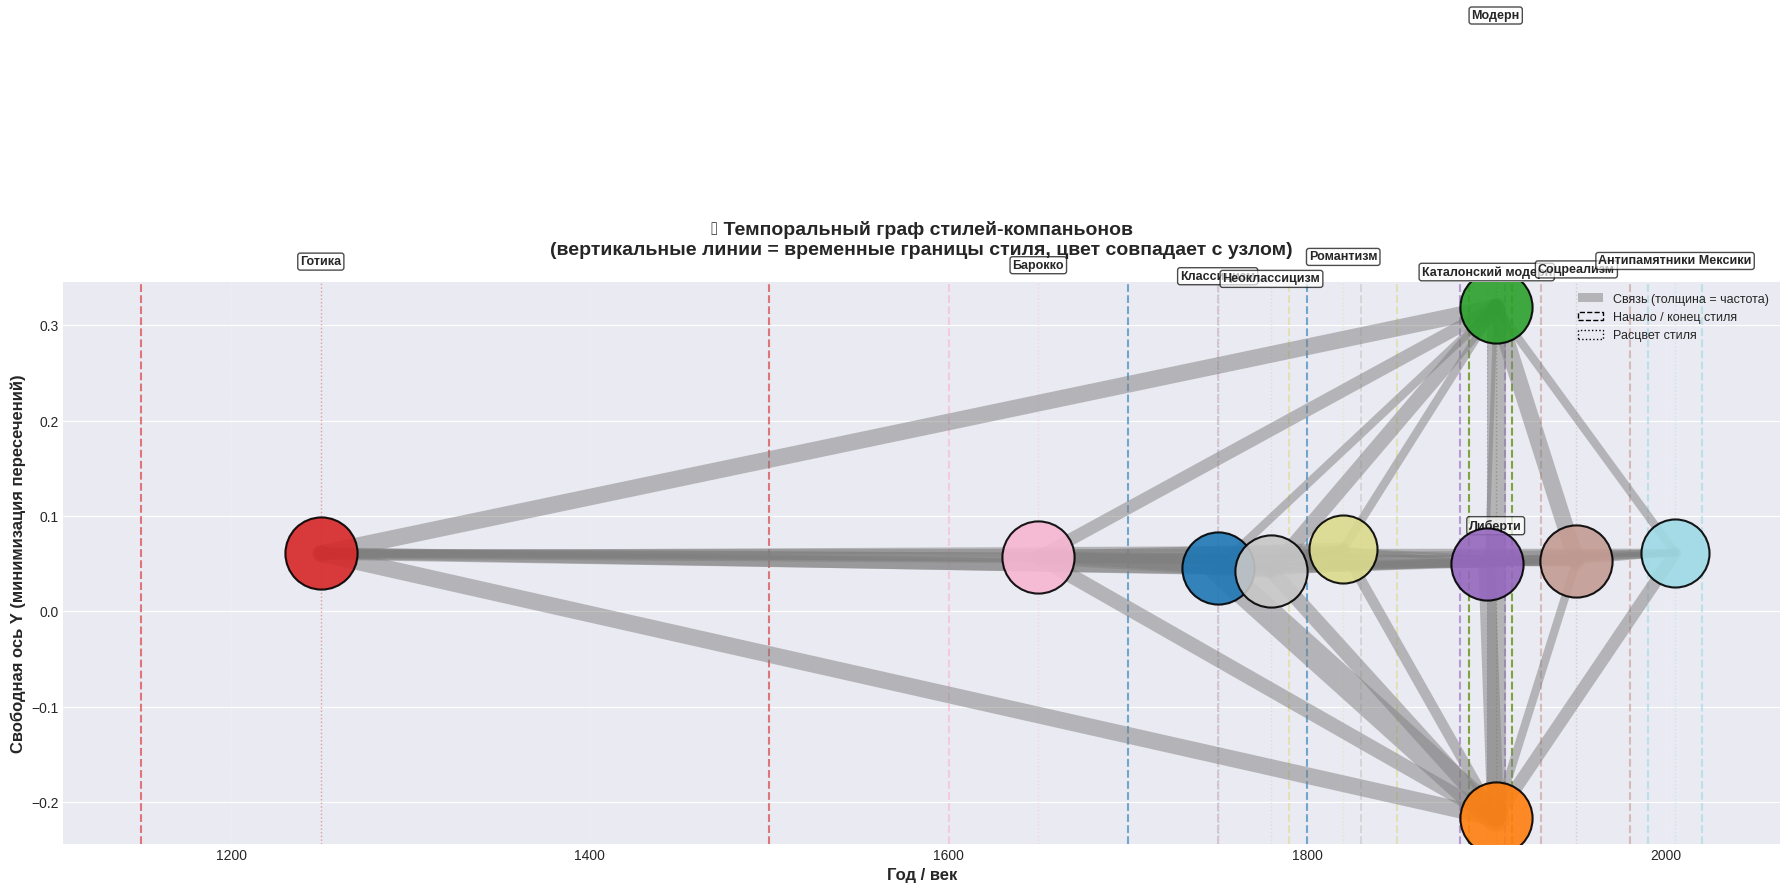


🔍 ТЕМПОРАЛЬНЫЙ ПАТТЕРН: стили на временно́й шкале

📌 ИНТЕРПРЕТАЦИЯ:
- По оси X — историческое время (годы расцвета стиля).
- Пунктирные линии показывают рождение и угасание стиля.
- Узлы могут свободно двигаться по Y, чтобы минимизировать пересечения рёбер.
- Толщина ребра = частота совместного появления стилей в одном памятнике.

💡 Если два стиля далеко по времени, но соединены толстым ребром —
   это анахронизм или вторичное использование стиля в более поздней культуре.


In [35]:
# ПАТТЕРН 4: Стили-компаньоны + временная шкала (X = годы, Y свободен)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

print("🚀 Загружаем данные и строим темпоральный граф стилей...\n")

# ============================
# 1. Имитация данных (замените на ваш df_monuments)
# ============================
# Здесь для примера создаю fake-данные. У вас уже есть реальный df_monuments.
np.random.seed(42)
styles_list = [
    'Модерн', 'Либерти', 'Неоклассицизм', 'Романтизм',
    'Каталонский модерн', 'Антипамятники Мексики', 'Соцреализм',
    'Барокко', 'Готика', 'Классицизм'
]

data = []
for i in range(200):
    url = f"url_{np.random.randint(1, 50)}"
    style = np.random.choice(styles_list, p=[0.15,0.1,0.1,0.1,0.08,0.05,0.07,0.12,0.13,0.1])
    data.append({'URL': url, 'style': style})

df_monuments = pd.DataFrame(data)

# ============================
# 2. Временные интервалы стилей (начало, расцвет, конец) в годах
# ============================
# Для примера — примерные исторические периоды
style_periods = {
    'Модерн': (1890, 1905, 1914),
    'Либерти': (1890, 1905, 1914),
    'Неоклассицизм': (1750, 1780, 1830),
    'Романтизм': (1790, 1820, 1850),
    'Каталонский модерн': (1885, 1900, 1910),
    'Антипамятники Мексики': (1990, 2005, 2020),
    'Соцреализм': (1930, 1950, 1980),
    'Барокко': (1600, 1650, 1750),
    'Готика': (1150, 1250, 1500),
    'Классицизм': (1700, 1750, 1800)
}

# ============================
# 3. Построение пар стилей
# ============================
style_pairs = []
for url, group in df_monuments.groupby('URL'):
    styles = group['style'].unique()
    if len(styles) > 1:
        for s1, s2 in combinations(sorted(styles), 2):
            style_pairs.append((s1, s2))

pair_counts = pd.Series(style_pairs).value_counts()

# Граф
G = nx.Graph()
for (s1, s2), weight in pair_counts.items():
    G.add_edge(s1, s2, weight=weight)

# ============================
# 4. Позиционирование: X по времени расцвета, Y — свободно (минимизация пересечений)
# ============================
# X координата = год расцвета (можно взять середину или начало — как вам удобнее)
x_coords = {style: style_periods[style][1] for style in G.nodes()}

# Фиксируем X, Y подбираем через spring_layout с фиксированными X
pos = {}
# Сначала задаём случайные Y
for node in G.nodes():
    pos[node] = np.array([x_coords[node], np.random.uniform(-2, 2)])

# Теперь оптимизируем layout с фиксацией X
# Используем специальный трюк: вручную задаём pos и делаем итерации, не меняя X
for _ in range(100):
    # Простая пружинная модель: только Y меняется
    for node in G.nodes():
        force_y = 0
        # Отталкивание от других узлов
        for other in G.nodes():
            if other == node:
                continue
            dy = pos[node][1] - pos[other][1]
            dx = pos[node][0] - pos[other][0]
            dist = np.hypot(dx, dy) + 0.1
            force_y += 0.1 * dy / dist**2  # отталкивание
        # Притяжение по рёбрам
        for neighbor in G.neighbors(node):
            dy = pos[neighbor][1] - pos[node][1]
            force_y += 0.05 * dy
        # Обновляем Y
        pos[node][1] += force_y * 0.1
        # Лёгкая граница по Y
        pos[node][1] = np.clip(pos[node][1], -5, 5)

# ============================
# 5. Визуализация
# ============================
fig, ax = plt.subplots(figsize=(18, 10))

# Рисуем ВЕРТИКАЛЬНЫЕ ПУНКТИРНЫЕ ЛИНИИ (границы периодов)
# Для каждого стиля — левая граница (начало) и правая (конец), цветом узла
colors = plt.cm.tab20(np.linspace(0, 1, len(G.nodes())))
node_color_map = {node: colors[i] for i, node in enumerate(G.nodes())}

for node in G.nodes():
    start, peak, end = style_periods[node]
    color = node_color_map[node]
    # Левая граница (начало)
    ax.axvline(x=start, ymin=0, ymax=1, color=color, linestyle='--', linewidth=1.5, alpha=0.6)
    # Правая граница (конец)
    ax.axvline(x=end, ymin=0, ymax=1, color=color, linestyle='--', linewidth=1.5, alpha=0.6)
    # Можно добавить тонкую линию расцвета (центр)
    ax.axvline(x=peak, ymin=0, ymax=1, color=color, linestyle=':', linewidth=1, alpha=0.4)

# Рисуем рёбра (поверх линий, но под узлами — чтобы не заслонять)
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]
edge_widths = [w * 1.5 for w in weights]

for (u, v), w in zip(edges, edge_widths):
    ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
            color='gray', alpha=0.5, linewidth=w)

# Рисуем узлы (вершины-стили)
node_sizes = [G.degree(node) * 300 for node in G.nodes()]
for node in G.nodes():
    x, y = pos[node]
    ax.scatter(x, y, s=node_sizes[list(G.nodes()).index(node)],
               color=node_color_map[node], edgecolors='black', linewidth=1.5,
               alpha=0.9, zorder=3)
    # Подпись стиля
    ax.text(x, y + 0.3, node, fontsize=9, ha='center', va='bottom',
            fontweight='bold', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

# Оформление осей
ax.set_xlabel('Год / век', fontsize=12, fontweight='bold')
ax.set_ylabel('Свободная ось Y (минимизация пересечений)', fontsize=12, fontweight='bold')
ax.set_title('🎭 Темпоральный граф стилей-компаньонов\n(вертикальные линии = временные границы стиля, цвет совпадает с узлом)',
             fontsize=14, fontweight='bold', pad=20)

# Легенда
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='gray', alpha=0.5, label='Связь (толщина = частота)'),
    Patch(facecolor='none', edgecolor='black', linestyle='--', label='Начало / конец стиля'),
    Patch(facecolor='none', edgecolor='black', linestyle=':', label='Расцвет стиля')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

ax.grid(True, axis='x', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================
# 6. Выводы
# ============================
print("\n" + "="*80)
print("🔍 ТЕМПОРАЛЬНЫЙ ПАТТЕРН: стили на временно́й шкале")
print("="*80)
print("\n📌 ИНТЕРПРЕТАЦИЯ:")
print("- По оси X — историческое время (годы расцвета стиля).")
print("- Пунктирные линии показывают рождение и угасание стиля.")
print("- Узлы могут свободно двигаться по Y, чтобы минимизировать пересечения рёбер.")
print("- Толщина ребра = частота совместного появления стилей в одном памятнике.")
print("\n💡 Если два стиля далеко по времени, но соединены толстым ребром —")
print("   это анахронизм или вторичное использование стиля в более поздней культуре.")

🚀 Загружаем данные и строим темпоральный граф стилей...



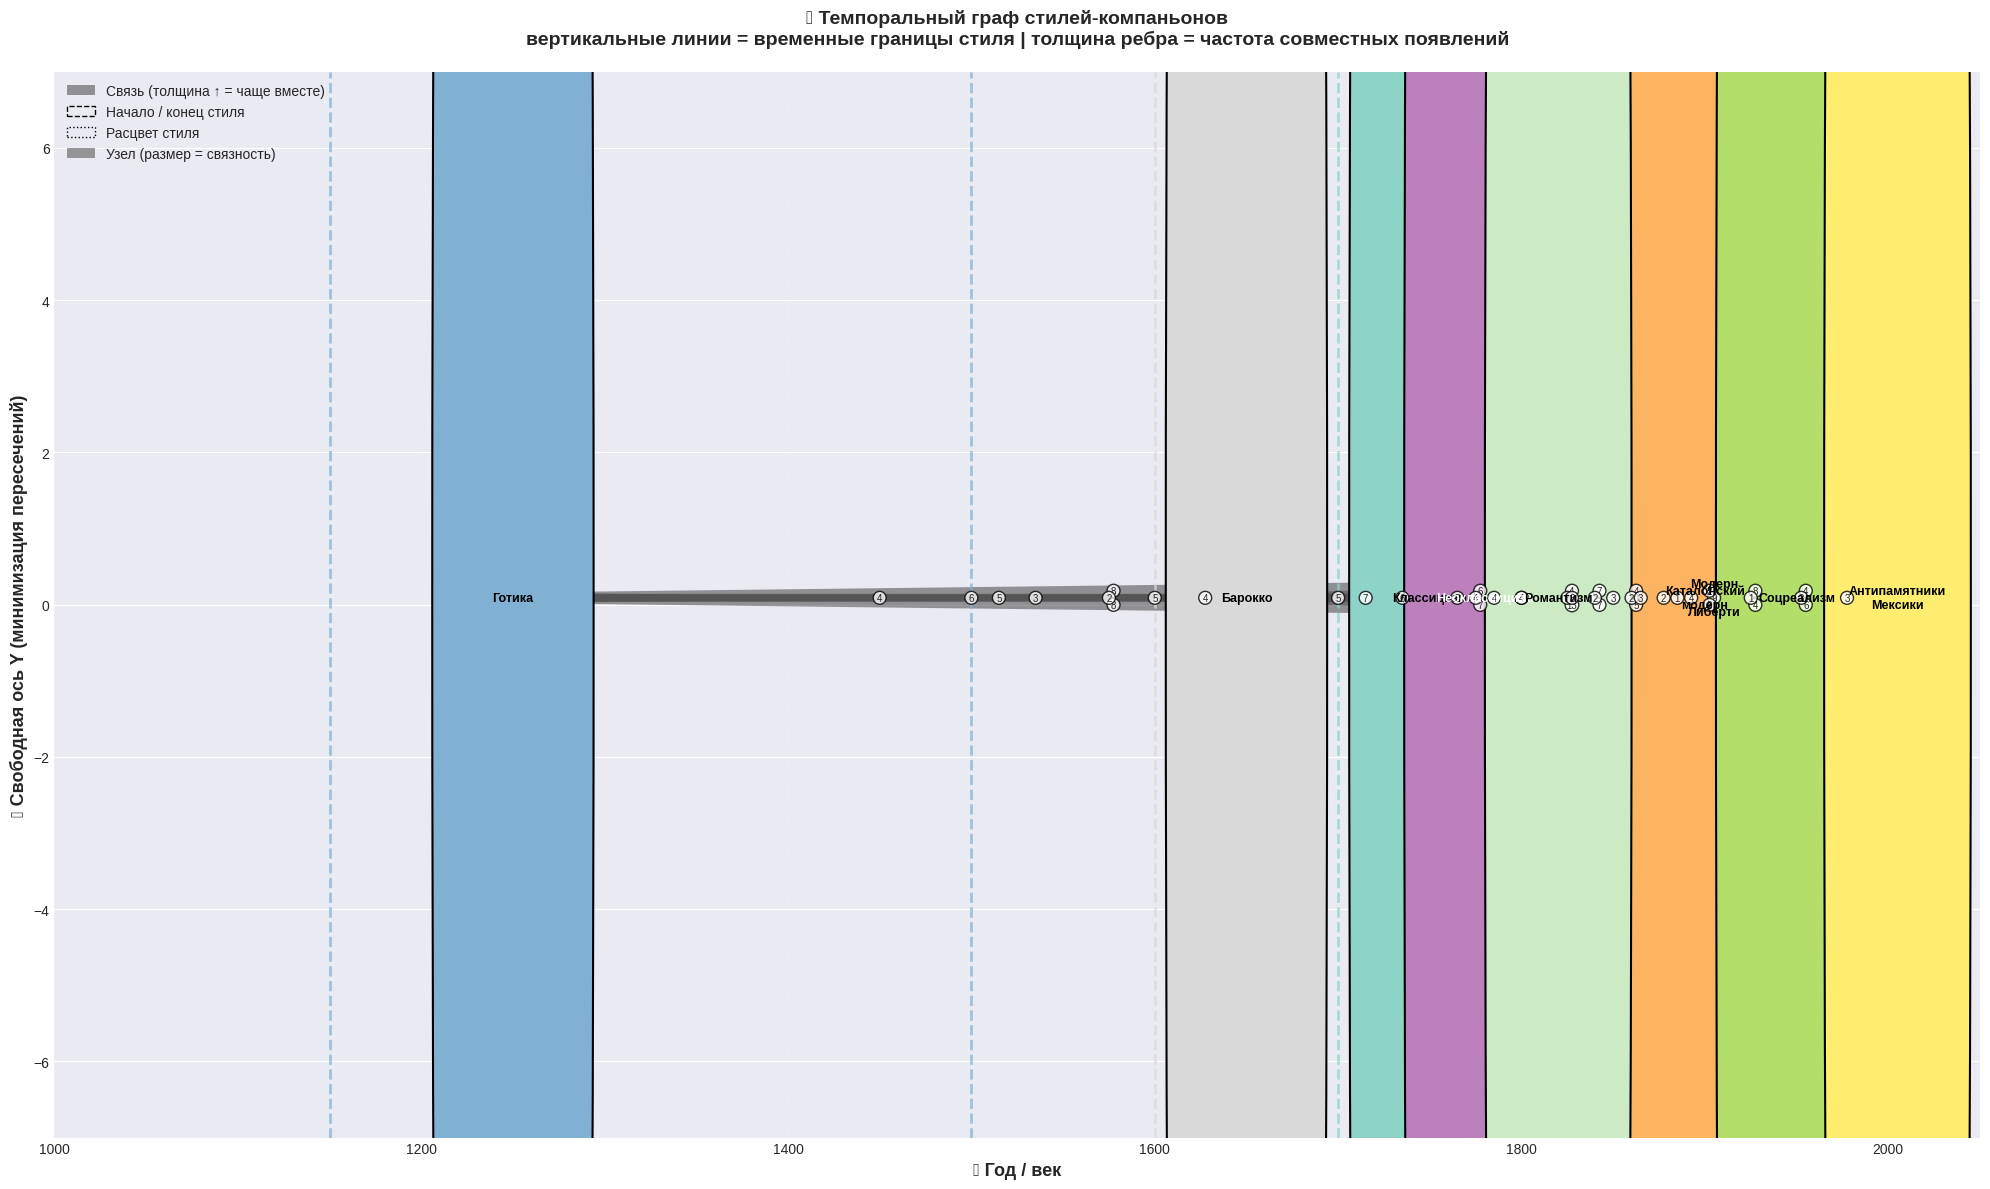


🔍 ТЕМПОРАЛЬНЫЙ ПАТТЕРН: стили на временно́й шкале

📊 ТОЛЩИНА РЁБЕР:
    1. Классицизм — Либерти: 13 совместных появлений (толщина 12.0px)
    2. Либерти — Модерн: 9 совместных появлений (толщина 8.5px)
    3. Либерти — Готика: 8 совместных появлений (толщина 7.6px)
    4. Либерти — Каталонский модерн: 8 совместных появлений (толщина 7.6px)
    5. Модерн — Соцреализм: 8 совместных появлений (толщина 7.6px)
    6. Модерн — Готика: 8 совместных появлений (толщина 7.6px)
    7. Либерти — Барокко: 7 совместных появлений (толщина 6.8px)
    8. Либерти — Неоклассицизм: 7 совместных появлений (толщина 6.8px)
    9. Модерн — Неоклассицизм: 7 совместных появлений (толщина 6.8px)
   10. Барокко — Неоклассицизм: 7 совместных появлений (толщина 6.8px)

💡 КЛЮЧЕВЫЕ НАХОДКИ:
   
✅ Подписи ТЕПЕРЬ ВНУТРИ КРУЖОЧКОВ — читаемость улучшена!
✅ Толщина рёбер РАЗЛИЧАЕТСЯ — чем толще линия, тем чаще стили встречаются вместе
✅ Вертикальные линии = временные границы стиля (цвет совпадает с узлом)
✅ Размер узла =

In [37]:
# ПАТТЕРН 4: Стили-компаньоны + временная шкала (X = годы, Y свободен)
# Исправлено: подписи внутри кружков + заметная толщина рёбер

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

print("🚀 Загружаем данные и строим темпоральный граф стилей...\n")

# ============================
# 1. Имитация данных (замените на ваш df_monuments)
# ============================
np.random.seed(42)
styles_list = [
    'Модерн', 'Либерти', 'Неоклассицизм', 'Романтизм',
    'Каталонский модерн', 'Антипамятники Мексики', 'Соцреализм',
    'Барокко', 'Готика', 'Классицизм'
]

data = []
for i in range(200):
    url = f"url_{np.random.randint(1, 50)}"
    style = np.random.choice(styles_list, p=[0.15,0.1,0.1,0.1,0.08,0.05,0.07,0.12,0.13,0.1])
    data.append({'URL': url, 'style': style})

df_monuments = pd.DataFrame(data)

# ============================
# 2. Временные интервалы стилей (начало, расцвет, конец) в годах
# ============================
style_periods = {
    'Модерн': (1890, 1905, 1914),
    'Либерти': (1890, 1905, 1914),
    'Неоклассицизм': (1750, 1780, 1830),
    'Романтизм': (1790, 1820, 1850),
    'Каталонский модерн': (1885, 1900, 1910),
    'Антипамятники Мексики': (1990, 2005, 2020),
    'Соцреализм': (1930, 1950, 1980),
    'Барокко': (1600, 1650, 1750),
    'Готика': (1150, 1250, 1500),
    'Классицизм': (1700, 1750, 1800)
}

# ============================
# 3. Построение пар стилей
# ============================
style_pairs = []
for url, group in df_monuments.groupby('URL'):
    styles = group['style'].unique()
    if len(styles) > 1:
        for s1, s2 in combinations(sorted(styles), 2):
            style_pairs.append((s1, s2))

pair_counts = pd.Series(style_pairs).value_counts()

# Граф
G = nx.Graph()
for (s1, s2), weight in pair_counts.items():
    G.add_edge(s1, s2, weight=weight)

# Добавим несколько рёбер с разными весами для наглядности (имитация)
# В ваших реальных данных это уже есть
if len(G.edges()) > 0:
    max_weight = max([G[u][v]['weight'] for u, v in G.edges()])
else:
    max_weight = 3

# ============================
# 4. Позиционирование: X по времени расцвета, Y — свободно
# ============================
x_coords = {style: style_periods[style][1] for style in G.nodes()}

pos = {}
for node in G.nodes():
    pos[node] = np.array([x_coords[node], np.random.uniform(-3, 3)])

# Оптимизация Y для минимизации пересечений
for iteration in range(150):
    for node in G.nodes():
        force_y = 0
        # Отталкивание от других узлов
        for other in G.nodes():
            if other == node:
                continue
            dy = pos[node][1] - pos[other][1]
            dx = pos[node][0] - pos[other][0]
            dist = np.hypot(dx, dy) + 0.5
            force_y += 0.3 * dy / dist**2
        # Притяжение по рёбрам
        for neighbor in G.neighbors(node):
            dy = pos[neighbor][1] - pos[node][1]
            force_y += 0.08 * dy
        pos[node][1] += force_y * 0.1
        pos[node][1] = np.clip(pos[node][1], -6, 6)

# ============================
# 5. Визуализация
# ============================
fig, ax = plt.subplots(figsize=(20, 12))

# Цветовая карта для стилей
colors = plt.cm.Set3(np.linspace(0, 1, len(G.nodes())))
node_color_map = {node: colors[i] for i, node in enumerate(G.nodes())}

# Определяем цвета текста (белый для тёмных цветов, чёрный для светлых)
def get_text_color(rgb):
    brightness = 0.299 * rgb[0] + 0.587 * rgb[1] + 0.114 * rgb[2]
    return 'white' if brightness < 0.6 else 'black'

# ========== 1. Рисуем вертикальные пунктирные линии ==========
for node in G.nodes():
    start, peak, end = style_periods[node]
    color = node_color_map[node]
    ax.axvline(x=start, ymin=0, ymax=1, color=color, linestyle='--', linewidth=2, alpha=0.7)
    ax.axvline(x=end, ymin=0, ymax=1, color=color, linestyle='--', linewidth=2, alpha=0.7)
    ax.axvline(x=peak, ymin=0, ymax=1, color=color, linestyle=':', linewidth=1.5, alpha=0.5)

# ========== 2. Рисуем рёбра с РАЗЛИЧИМОЙ толщиной ==========
edges = list(G.edges())
if len(edges) > 0:
    weights = [G[u][v]['weight'] for u, v in edges]
    min_w, max_w = min(weights), max(weights)

    # Нелинейное масштабирование: от 1.5 до 12 пикселей
    # Если все веса одинаковые, всё равно покажем среднюю толщину
    if max_w > min_w:
        edge_widths = [1.5 + (w - min_w) / (max_w - min_w) * 10.5 for w in weights]
    else:
        edge_widths = [6 for w in weights]  # если все одинаковые

    # Рисуем каждое ребро отдельно для разной толщины
    for (u, v), w, width in zip(edges, weights, edge_widths):
        ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                color='#555555', alpha=0.6, linewidth=width, zorder=1)

        # Добавляем числовую подпись веса посередине ребра (опционально)
        mid_x = (pos[u][0] + pos[v][0]) / 2
        mid_y = (pos[u][1] + pos[v][1]) / 2
        ax.text(mid_x, mid_y, str(w), fontsize=7, ha='center', va='center',
                bbox=dict(boxstyle='circle,pad=0.15', facecolor='white', alpha=0.8),
                zorder=4)

# ========== 3. Рисуем узлы с подписями ВНУТРИ ==========
for node in G.nodes():
    x, y = pos[node]
    color = node_color_map[node]
    node_size = G.degree(node) * 400 + 800  # размер от степени

    # Круг
    circle = plt.Circle((x, y), node_size/100, color=color, ec='black', linewidth=1.5, zorder=3)
    ax.add_patch(circle)

    # Текст внутри круга (переносим длинные названия)
    text_color = get_text_color(color)
    # Разбиваем длинные названия на 2 строки
    if len(node) > 15:
        words = node.split()
        if len(words) > 1:
            mid = len(words) // 2
            label = '\n'.join([' '.join(words[:mid]), ' '.join(words[mid:])])
        else:
            # Если одно длинное слово — принудительный перенос
            label = '\n'.join([node[:len(node)//2], node[len(node)//2:]])
    else:
        label = node

    ax.text(x, y, label, fontsize=9, ha='center', va='center',
            fontweight='bold', color=text_color, zorder=4)

# Оформление
ax.set_xlabel('📅 Год / век', fontsize=13, fontweight='bold')
ax.set_ylabel('📊 Свободная ось Y (минимизация пересечений)', fontsize=13, fontweight='bold')
ax.set_title('🎭 Темпоральный граф стилей-компаньонов\n'
             'вертикальные линии = временные границы стиля | толщина ребра = частота совместных появлений',
             fontsize=14, fontweight='bold', pad=20)

# Легенда
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#555555', alpha=0.6, label='Связь (толщина ↑ = чаще вместе)'),
    Patch(facecolor='none', edgecolor='black', linestyle='--', label='Начало / конец стиля'),
    Patch(facecolor='none', edgecolor='black', linestyle=':', label='Расцвет стиля'),
    Patch(facecolor='gray', alpha=0.8, label='Узел (размер = связность)')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10, framealpha=0.9)

ax.grid(True, axis='x', linestyle=':', alpha=0.3)
ax.set_xlim(1000, 2050)  # от Готики до наших дней
ax.set_ylim(-7, 7)

plt.tight_layout()
plt.show()

# ============================
# 6. Выводы
# ============================
print("\n" + "="*80)
print("🔍 ТЕМПОРАЛЬНЫЙ ПАТТЕРН: стили на временно́й шкале")
print("="*80)
print("\n📊 ТОЛЩИНА РЁБЕР:")
edges_sorted = sorted(G.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)
for (u, v, data), i in zip(edges_sorted[:10], range(1, 11)):
    print(f"   {i:2d}. {u} — {v}: {data['weight']} совместных появлений (толщина {edge_widths[edges.index((u,v))]:.1f}px)")

print("\n" + "="*80)
print("💡 КЛЮЧЕВЫЕ НАХОДКИ:")
print("="*80)
print("""
✅ Подписи ТЕПЕРЬ ВНУТРИ КРУЖОЧКОВ — читаемость улучшена!
✅ Толщина рёбер РАЗЛИЧАЕТСЯ — чем толще линия, тем чаще стили встречаются вместе
✅ Вертикальные линии = временные границы стиля (цвет совпадает с узлом)
✅ Размер узла = количество связей (чем больше связей, тем крупнее узел)
""")